In [1]:
# ================================
# 二手车价格预测分析系统
# 功能：对燃油车和新能源车进行价格预测分析
# 作者：[赵哲弘]
# 日期：2025年12月
# ================================

# 第一部分：导入必要的库和模块
# ================================
# 基础数据处理库 - 用于数值计算和数据分析
import numpy as np  # 数值计算库，提供高效的数组操作
import pandas as pd  # 数据分析库，提供DataFrame数据结构
import warnings
warnings.filterwarnings('ignore')  # 忽略警告信息，使输出更整洁

# 机器学习模型 - 用于构建预测模型
from sklearn.linear_model import LinearRegression  # 线性回归模型
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # 集成学习模型
from sklearn.svm import SVR  # 支持向量机回归

# 数据预处理 - 用于数据清洗和转换
from sklearn.preprocessing import StandardScaler, LabelEncoder  # 特征缩放和标签编码
from sklearn.impute import SimpleImputer  # 缺失值填充
from sklearn.model_selection import train_test_split, cross_val_score  # 数据分割和交叉验证

# 特征工程 - 用于文本特征提取
from sklearn.feature_selection import SelectKBest, f_regression  # 特征选择
from sklearn.feature_extraction.text import TfidfVectorizer  # 文本特征提取

# 模型评估 - 用于评估模型性能
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # 评估指标

# 模型持久化 - 用于保存和加载模型
import joblib  # 模型保存和加载

# 可视化库 - 用于数据可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [2]:
# 第二部分：数据加载与探索
# ================================
# 读取数据文件
# 注意：不同文件可能使用不同的编码方式
dfxny = pd.read_csv('../data/新能源.csv', encoding='gbk')  # 新能源车数据，使用GBK编码
dfqy = pd.read_csv('../data/汽油.csv', encoding='utf-8')  # 燃油车数据，使用UTF-8编码

# 筛选核心列，提高处理效率
core_columns = ['标题', '品牌', '城市', '购买年份', '里程', '过户次数', '原价', '售价']
dfxny = dfxny[core_columns]  # 只保留这些列，忽略冗余文本列
dfqy = dfqy[core_columns]  # 对燃油车数据同样处理

In [3]:
# 第三部分：数据清洗函数
# ================================
def integrated_data_cleaning(df, current_year=2025, inplace=True):
    """
    整合的数据清洗函数
    功能：对二手车数据进行全面的清洗和预处理
    参数：
        df: 要清洗的DataFrame
        current_year: 当前年份，用于计算车龄
        inplace: 是否在原数据上修改
    返回：清洗后的DataFrame[7](@ref)
    """
    if not inplace:
        df_clean = df.copy()  # 创建数据副本，避免修改原数据
    else:
        df_clean = df
    
    # 1. 清洗价格列（处理"暂无报价"等特殊值）
    price_columns = ['售价', '原价']
    for col in price_columns:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].replace('暂无报价', np.nan)  # 替换特殊值为NaN
            df_clean[col] = df_clean[col].astype(str).str.replace('万', '', regex=False)  # 移除单位astype(str): 确保该列所有内容被视为字符串，
            # 避免对非字符串调用字符串方法报错。
            # str.replace('万', '', regex=False): 从字符串中移除“万”字。regex=False表示执行简单的字面替换而非正则表达式，效率更高也更安全
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')  # 转换为数值类型遇到无法转换的值时，
            # 不报错，而是将其替换为 NaN（Not a Number，Pandas中表示缺失值）
    
    # 2. 使用规则字典清理其他列
    cleanup_rules = {
        '里程': '万公里',  # 里程单位清理
        '购买年份': '年'    # 年份单位清理
    }
    
    for col, pattern in cleanup_rules.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.replace(pattern, '')  # 移除单位文本
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')  # 转换为数值
    
    # 3. 处理过户次数
    if '过户次数' in df_clean.columns:
        df_clean['过户次数'] = pd.to_numeric(df_clean['过户次数'], errors='coerce')
    
    # 4. 删除缺失值
    original_count = len(df_clean)  # 记录原始数据量
    df_clean.dropna(inplace=True)  # 删除包含缺失值的行
    cleaned_count = len(df_clean)  # 清洗后数据量
    
    # 5. 计算车龄
    if '购买年份' in df_clean.columns:
        df_clean['购买年份'] = df_clean['购买年份'].astype(int)  # 确保年份为整数
        df_clean['车龄'] = current_year - df_clean['购买年份']  # 计算车龄
    
    # 6. 输出清洗结果
    print(f"数据清洗完成！")
    print(f"原始数据: {original_count} 条")
    print(f"清洗后数据: {cleaned_count} 条")
    print(f"删除无效数据: {original_count - cleaned_count} 条")
    
    return df_clean

# 应用数据清洗
dfqy_clean = integrated_data_cleaning(dfqy, inplace=True)  # 清洗燃油车数据
dfxny_clean = integrated_data_cleaning(dfxny, inplace=True)  # 清洗新能源车数据

数据清洗完成！
原始数据: 4500 条
清洗后数据: 4452 条
删除无效数据: 48 条
数据清洗完成！
原始数据: 4500 条
清洗后数据: 4451 条
删除无效数据: 49 条


In [4]:
dfqy_clean.isnull().sum()

标题      0
品牌      0
城市      0
购买年份    0
里程      0
过户次数    0
原价      0
售价      0
车龄      0
dtype: int64

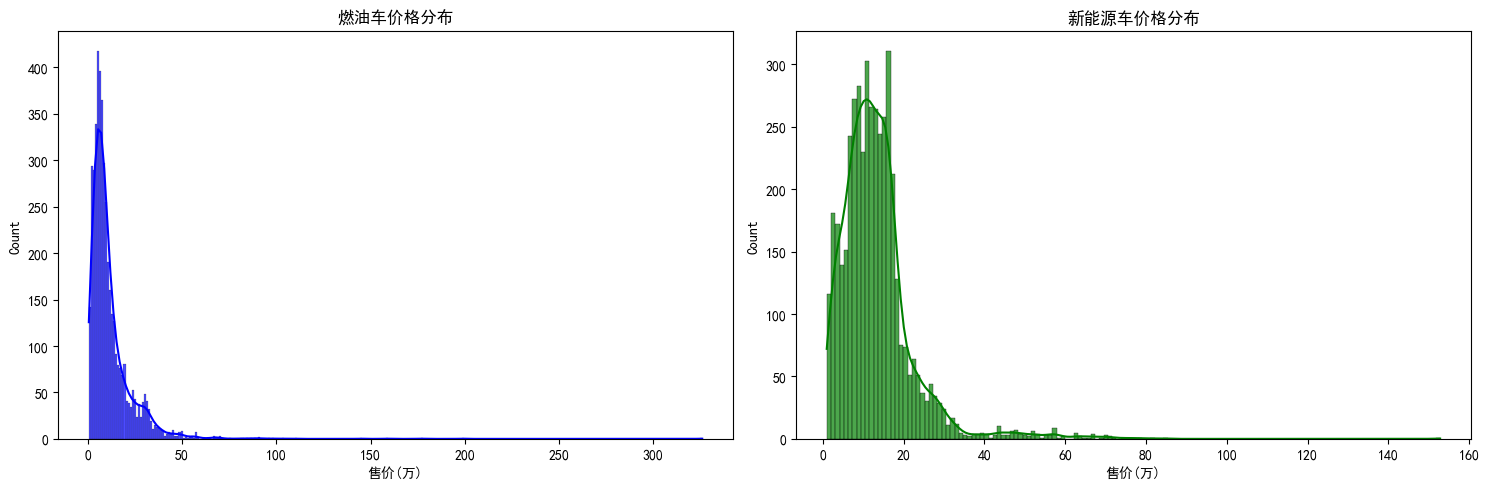

In [5]:
# 第四部分：数据可视化分析
# ================================
def plot_price_distribution(df_qy, df_xny):
    """
    绘制价格分布对比图
    功能：可视化燃油车和新能源车的价格分布差异
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    #一行两列子图 
    
    # 燃油车价格分布
    sns.histplot(df_qy['售价'], kde=True, ax=ax1, color='blue', alpha=0.7)
    # kde指定核密度估计曲线，ax指定画图区域，alpha指定透明度
    ax1.set_title('燃油车价格分布')
    ax1.set_xlabel('售价(万)')
    
    # 新能源车价格分布
    sns.histplot(df_xny['售价'], kde=True, ax=ax2, color='green', alpha=0.7)
    ax2.set_title('新能源车价格分布')
    ax2.set_xlabel('售价(万)')
    
    plt.tight_layout()
    # 在显示或保存图形前，调用tight_layout自动调整布局
    plt.show()

# 调用可视化函数
plot_price_distribution(dfqy_clean, dfxny_clean)



In [6]:
# 第五部分：特征工程与预处理
# ================================
def preprocess_before_split(dfqy, dfxny):
    """
    在数据分割前进行统一的预处理
    功能：确保训练集和测试集使用相同的编码标准[4](@ref)
    """
    # 合并两个数据集进行统一的编码
    df_combined = pd.concat([dfqy, dfxny], ignore_index=True)
    
    # 创建统一的编码器
    brand_encoder = LabelEncoder()  # 品牌编码器
    city_encoder = LabelEncoder()   # 城市编码器
    
    # 在所有数据上拟合编码器（避免数据泄露）
    brand_encoder.fit(df_combined['品牌'])
    city_encoder.fit(df_combined['城市'])
    
    # 分别应用编码到两个数据集
    dfqy_encoded = dfqy.copy()
    dfxny_encoded = dfxny.copy()
    
    dfqy_encoded['品牌编码'] = brand_encoder.transform(dfqy['品牌'])
    dfxny_encoded['品牌编码'] = brand_encoder.transform(dfxny['品牌'])
    
    dfqy_encoded['城市编码'] = city_encoder.transform(dfqy['城市'])
    dfxny_encoded['城市编码'] = city_encoder.transform(dfxny['城市'])
    
    return dfqy_encoded, dfxny_encoded, brand_encoder, city_encoder

# 应用预处理
dfqy_encoded, dfxny_encoded, brand_encoder, city_encoder = preprocess_before_split(
    dfqy_clean, dfxny_clean
)

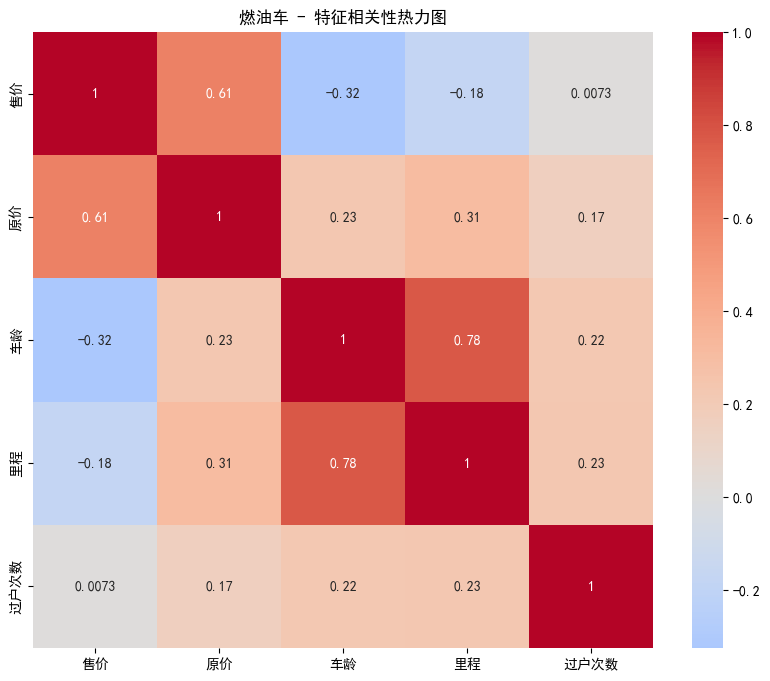

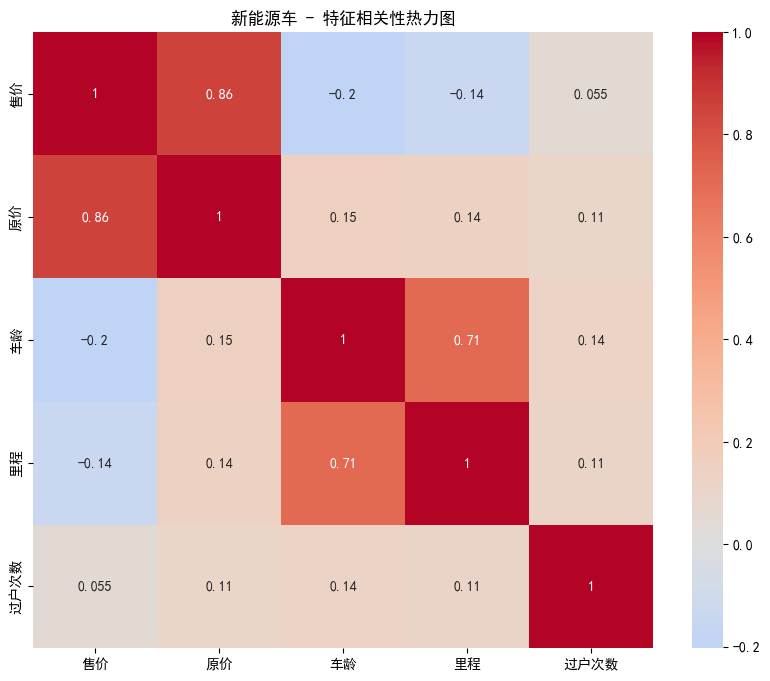

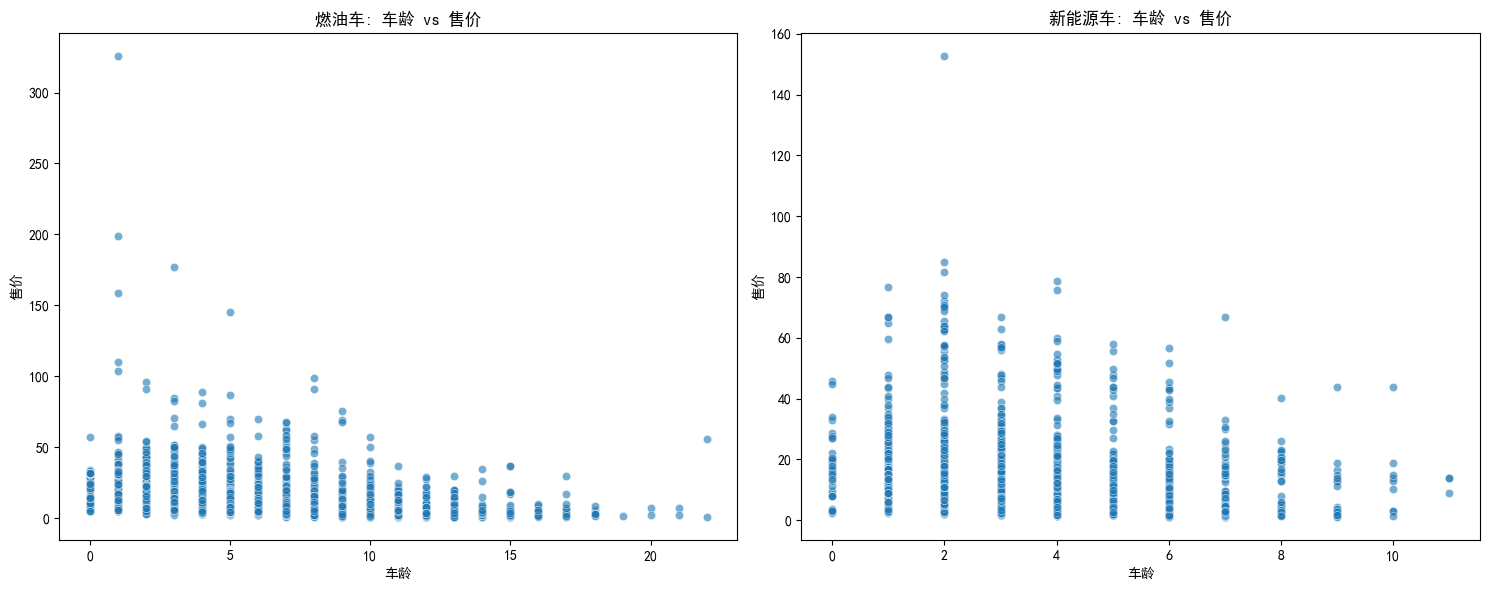

In [7]:
# 第五部分附加：特征相关性热力图以及车龄与价格关系散点图
# ================================
#5.1 特征相关性热力图
def plot_correlation_heatmap(df, title):
    # 选择数值特征计算相关性
    numerical_features = ['售价', '原价', '车龄', '里程', '过户次数']
    available_features = [col for col in numerical_features if col in df.columns]
    
    if available_features:
        corr_matrix = df[available_features].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title(f'{title} - 特征相关性热力图')
        plt.show()

# 5.2 车龄与价格关系散点图
def plot_age_vs_price(df_qy, df_xny):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    sns.scatterplot(data=df_qy, x='车龄', y='售价', alpha=0.6, ax=ax1)
    ax1.set_title('燃油车: 车龄 vs 售价')
    
    sns.scatterplot(data=df_xny, x='车龄', y='售价', alpha=0.6, ax=ax2)
    ax2.set_title('新能源车: 车龄 vs 售价')
    
    plt.tight_layout()
    plt.show()

# 调用可视化函数
plot_correlation_heatmap(dfqy_clean, "燃油车")
plot_correlation_heatmap(dfxny_clean, "新能源车")
plot_age_vs_price(dfqy_clean, dfxny_clean)

In [8]:
# 第六部分：数据分割与特征工程
# ================================
# 数据集的分割
# 对燃油车数据(dfqy)进行分割
X_qy = dfqy_encoded.drop('售价', axis=1)  # 特征：除售价外的所有列
y_qy = dfqy_encoded['售价']              # 目标变量：售价

X_qy_train, X_qy_test, y_qy_train, y_qy_test = train_test_split(
    X_qy, y_qy, 
    test_size=0.2,   # 20%作为测试集，80%作为训练集
    random_state=42,  # 随机种子，确保结果可重现
    shuffle=True      # 打乱数据顺序
)

# 对新能源车数据(dfxny)进行分割
X_xny = dfxny_encoded.drop('售价', axis=1)
y_xny = dfxny_encoded['售价']

X_xny_train, X_xny_test, y_xny_train, y_xny_test = train_test_split(
    X_xny, y_xny, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

def prepare_features(df_train, df_test):
    """
    准备特征：处理文本特征和数值变量
    功能：将原始数据转换为机器学习模型可用的特征格式
    """
    # 复制数据避免修改原数据
    X_train_prepared = df_train.copy()
    X_test_prepared = df_test.copy()
    
    # 1. 文本特征提取（从标题中提取关键信息）
    # TF-IDF旨在量化一个词对于一份文档在一个文档集合中的重要程度

    tfidf = TfidfVectorizer(max_features=50, stop_words=['款', '型', '版'])
    title_train = tfidf.fit_transform(X_train_prepared['标题'])  # 训练集文本特征
    title_test = tfidf.transform(X_test_prepared['标题'])         # 测试集文本特征
    
    # 2. 选择数值特征
    numerical_cols = ['车龄', '里程', '过户次数', '原价', '品牌编码', '城市编码']
    available_numerical_cols = [col for col in numerical_cols if col in X_train_prepared.columns]
    
    X_train_numerical = X_train_prepared[available_numerical_cols]
    X_test_numerical = X_test_prepared[available_numerical_cols]
    
    # 3. 特征标准化（使不同尺度的特征具有可比性）
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_numerical)  # 拟合并转换训练集
    X_test_scaled = scaler.transform(X_test_numerical)        # 转换测试集
    
    # 4. 合并所有特征
    X_train_final = np.hstack([X_train_scaled, title_train.toarray()])
    X_test_final = np.hstack([X_test_scaled, title_test.toarray()])
    
    return X_train_final, X_test_final, tfidf, scaler

# 应用特征工程
X_qy_train_final, X_qy_test_final, tfidf_qy, scaler_qy = prepare_features(X_qy_train, X_qy_test)
X_xny_train_final, X_xny_test_final, tfidf_xny, scaler_xny = prepare_features(X_xny_train, X_xny_test)

In [9]:
# 第七部分：模型训练与评估
# ================================
def train_and_evaluate_linear_regression(X_train, y_train, X_test, y_test, model_name):
    """
    训练并评估线性回归模型
    功能：构建预测模型并评估其性能[4](@ref)
    """
    print(f"\n训练 {model_name} 模型...")
    
    # 创建并训练模型
    model = LinearRegression()
    model.fit(X_train, y_train)  # 使用训练数据拟合模型
    
    # 预测
    y_pred = model.predict(X_test)  # 对测试集进行预测
    
    # 评估模型性能
    mse = mean_squared_error(y_test, y_pred)  # 均方误差
    rmse = np.sqrt(mse)                       # 均方根误差
    r2 = r2_score(y_test, y_pred)             # 决定系数
    
    print(f"{model_name} 模型评估结果:")
    print(f"均方根误差 (RMSE): {rmse:.2f}")  # RMSE越小越好
    print(f"决定系数 (R²): {r2:.4f}")        # R²越接近1越好
    
    return model

# 训练模型
linear_qy_model = train_and_evaluate_linear_regression(
    X_qy_train_final, y_qy_train, X_qy_test_final, y_qy_test, "燃油车线性回归"
)

linear_xny_model = train_and_evaluate_linear_regression(
    X_xny_train_final, y_xny_train, X_xny_test_final, y_xny_test, "新能源车线性回归"
)


训练 燃油车线性回归 模型...
燃油车线性回归 模型评估结果:
均方根误差 (RMSE): 9.79
决定系数 (R²): 0.5725

训练 新能源车线性回归 模型...
新能源车线性回归 模型评估结果:
均方根误差 (RMSE): 3.85
决定系数 (R²): 0.8618


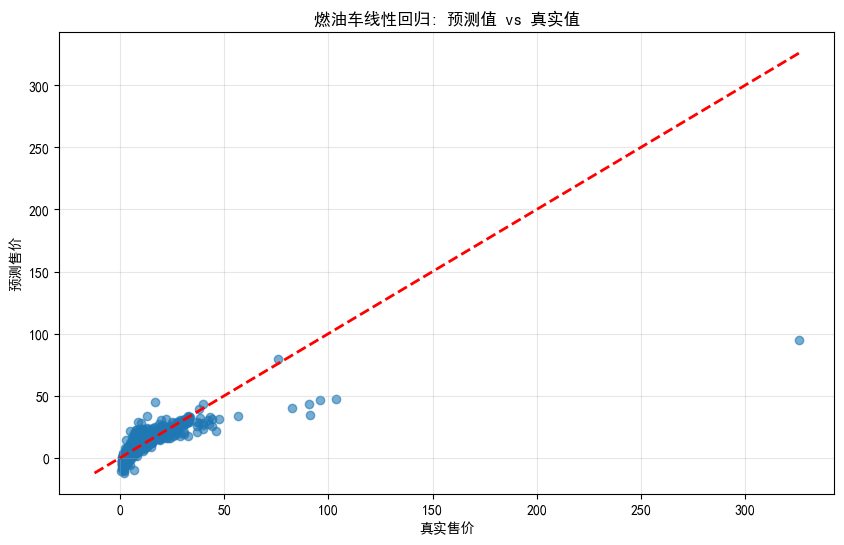

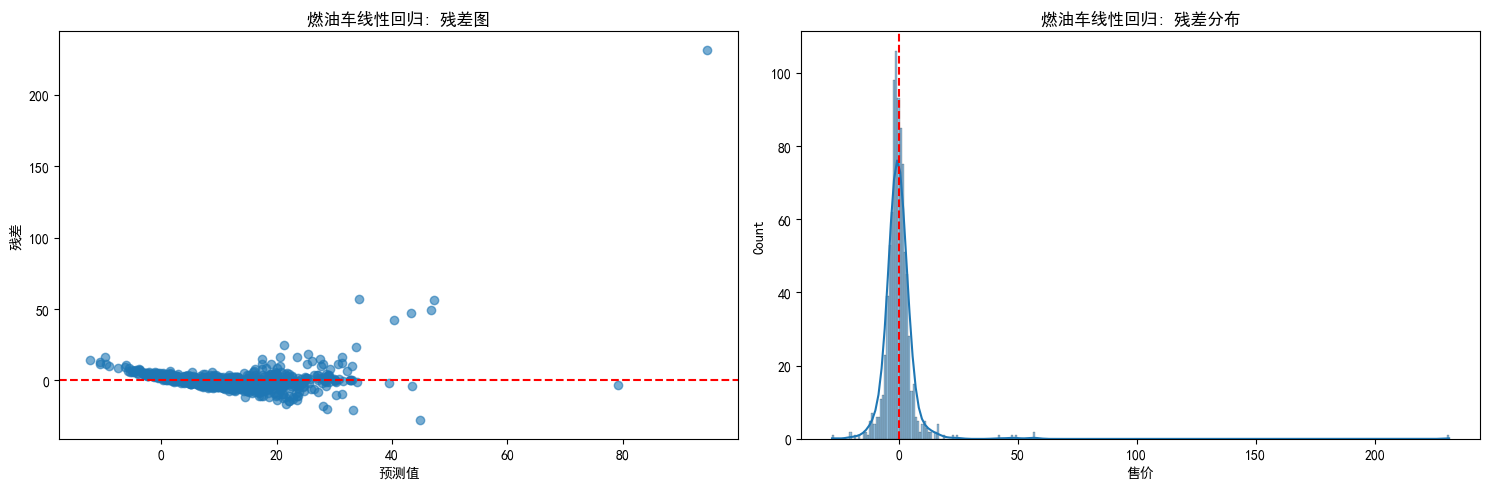

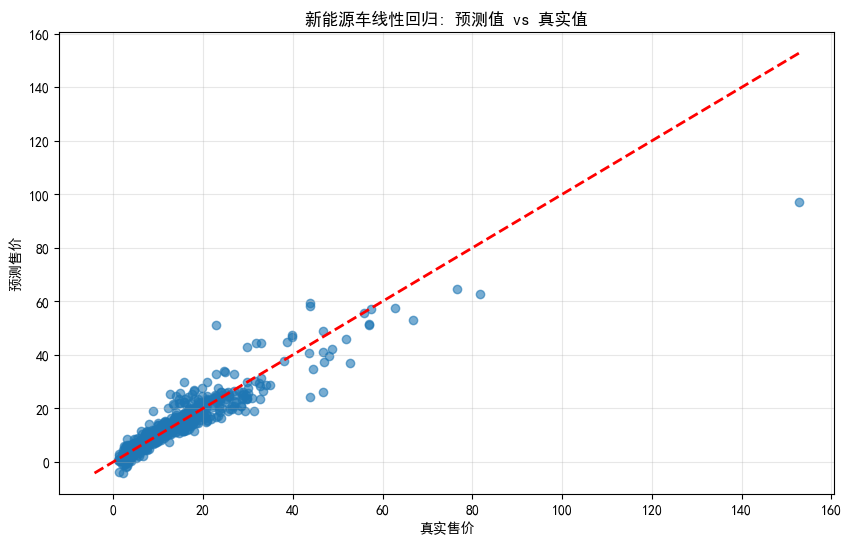

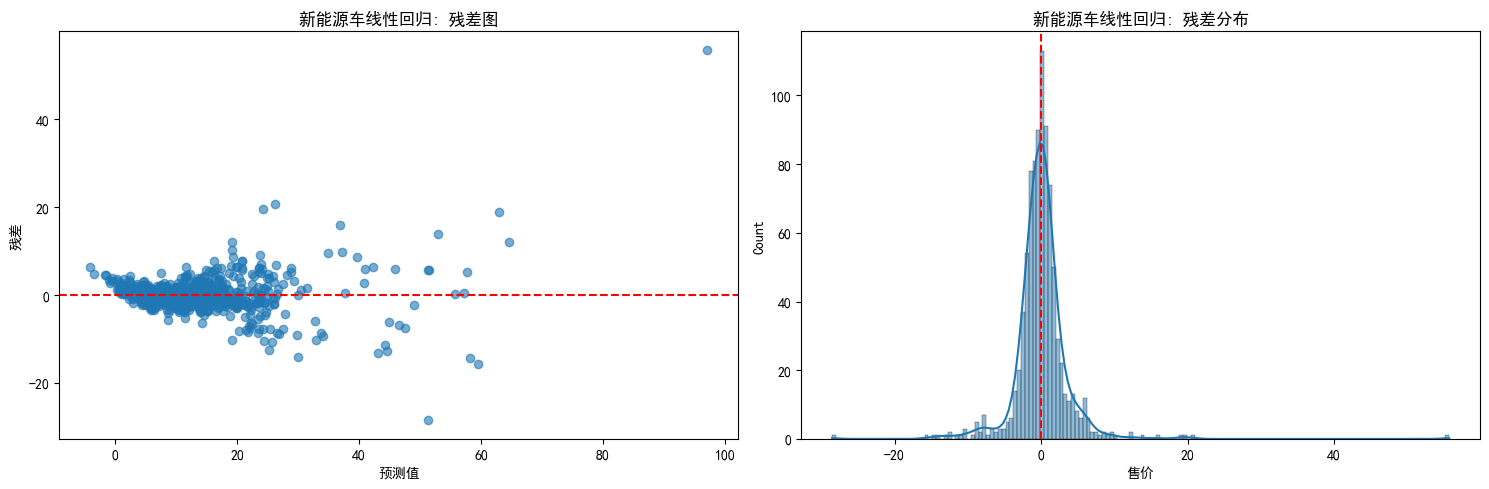

In [10]:
# 第八部分：预测结果可视化与模型评估
# ================================
# 8.1 预测值 vs 真实值散点图
def plot_predictions_vs_actual(y_true, y_pred, model_name):
    """
    绘制预测值与真实值的对比散点图
    功能：直观展示模型的预测准确性和误差分布
    参数：
        y_true: 真实值数组
        y_pred: 模型预测值数组  
        model_name: 模型名称（用于标题显示）
    """
    # 创建图形窗口
    plt.figure(figsize=(10, 6))
    
    # 创建散点图：每个点代表一个样本的真实值和预测值
    # alpha=0.6 设置透明度，避免点重叠时信息丢失
    plt.scatter(y_true, y_pred, alpha=0.6)
    
    # 添加理想拟合线（y=x的直线）
    # 如果预测完全准确，所有点都应落在这条线上
    max_val = max(max(y_true), max(y_pred))
    min_val = min(min(y_true), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    # 设置坐标轴标签和标题
    plt.xlabel('真实售价')
    plt.ylabel('预测售价')
    plt.title(f'{model_name}: 预测值 vs 真实值')
    plt.grid(True, alpha=0.3)  # 添加网格线，便于观察点的位置
    plt.show()

#8 .2 残差分布图
def plot_residuals(y_true, y_pred, model_name):
    """
    绘制残差分析图
    功能：分析预测误差的分布特征，检验模型假设的合理性
    参数：
        y_true: 真实值数组
        y_pred: 模型预测值数组
        model_name: 模型名称
    """
    # 计算残差（真实值 - 预测值）
    residuals = y_true - y_pred
    
    # 创建1行2列的子图布局
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # 子图1：残差散点图（残差 vs 预测值）
    ax1.scatter(y_pred, residuals, alpha=0.6)
    ax1.axhline(y=0, color='red', linestyle='--')  # 添加y=0参考线
    ax1.set_xlabel('预测值')
    ax1.set_ylabel('残差')
    ax1.set_title(f'{model_name}: 残差图')
    
    # 子图2：残差分布直方图
    sns.histplot(residuals, kde=True, ax=ax2)  # kde=True添加核密度估计曲线
    ax2.axvline(x=0, color='red', linestyle='--')  # 添加x=0参考线
    ax2.set_title(f'{model_name}: 残差分布')
    
    # 自动调整子图间距
    plt.tight_layout()
    plt.show()

# 在模型评估后调用可视化函数
# 对燃油车模型进行预测和可视化
y_qy_pred = linear_qy_model.predict(X_qy_test_final)
plot_predictions_vs_actual(y_qy_test, y_qy_pred, "燃油车线性回归")
plot_residuals(y_qy_test, y_qy_pred, "燃油车线性回归")

# 对新能源车模型进行预测和可视化  
y_xny_pred = linear_xny_model.predict(X_xny_test_final)
plot_predictions_vs_actual(y_xny_test, y_xny_pred, "新能源车线性回归")
plot_residuals(y_xny_test, y_xny_pred, "新能源车线性回归")

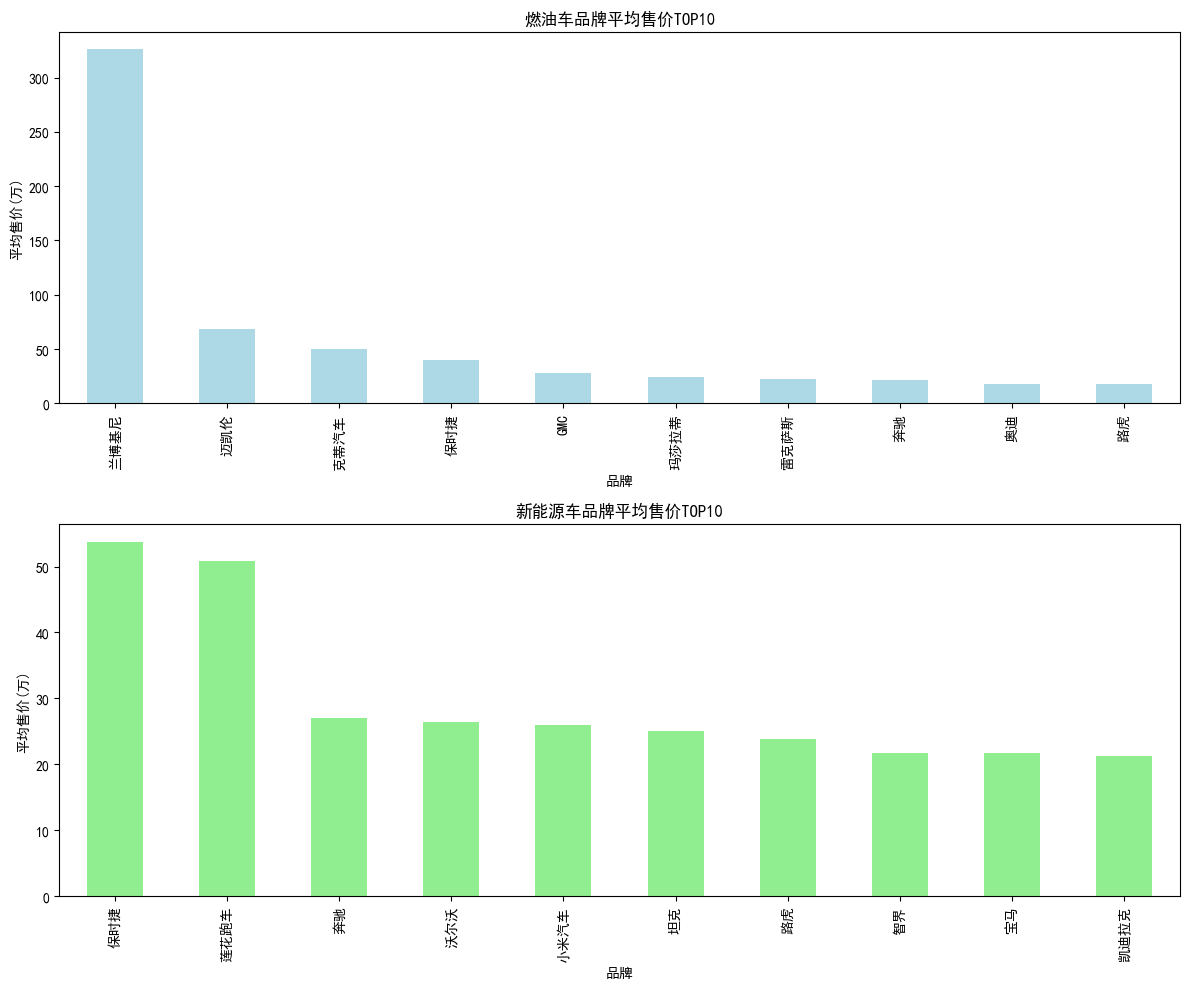

In [11]:
# 第九部分 品牌平均价格对比
def plot_brand_price_comparison(df_qy, df_xny):
    # 计算各品牌平均售价
    brand_avg_qy = df_qy.groupby('品牌')['售价'].mean().sort_values(ascending=False)
    brand_avg_xny = df_xny.groupby('品牌')['售价'].mean().sort_values(ascending=False)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    brand_avg_qy.head(10).plot(kind='bar', ax=ax1, color='lightblue')
    ax1.set_title('燃油车品牌平均售价TOP10')
    ax1.set_ylabel('平均售价(万)')
    
    brand_avg_xny.head(10).plot(kind='bar', ax=ax2, color='lightgreen')
    ax2.set_title('新能源车品牌平均售价TOP10')
    ax2.set_ylabel('平均售价(万)')
    
    plt.tight_layout()
    plt.show()

plot_brand_price_comparison(dfqy_clean, dfxny_clean)